# Food Delivery Time Prediction

Predicting food delivery time using order, rider, traffic and weather data,
instead of relying on distance alone.

Final model: Tuned XGBoost | Test MAE: 3.04 min | R2 Score: 0.837

![System Architecture](architecture_diagram.png)

## Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("Tools loaded successfully.")

Tools loaded successfully.


## Load Dataset

In [ ]:
import pandas as pd

# Loads the dataset directly from GitHub so the notebook runs without
# needing a manual file upload. Replace with your own raw file link.
CSV_URL = "PASTE_YOUR_GITHUB_RAW_CSV_URL_HERE"

try:
    df = pd.read_csv(CSV_URL)
except Exception:
    # fallback: manual upload if the URL isn't set up yet
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv('Zomato Dataset.csv')

print("Data loaded. Shape:", df.shape)
df.head()

## EDA — Structural & Shape Checks

In [ ]:
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nRandom sample (5 rows) — helps spot pattern bias:")
print(df.sample(5, random_state=42))

print("\nShape (rows, columns):", df.shape)

print("\nInfo (dtypes, non-null counts, memory):")
df.info()


## EDA — Data Quality & Missing Values (Raw)

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing % per column:")
print(((df.isnull().sum() / len(df)) * 100).round(2))

print("\nFully duplicate rows:", df.duplicated().sum())


## EDA — Statistical Summaries

In [ ]:
print("Numeric column summary:")
print(df.describe())

print("\nCategorical column summary:")
print(df.describe(include=['object']))

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


## EDA — Cardinality & Distribution Checks

In [ ]:
print("Unique value count per column:")
print(df.nunique())

print("\nValue counts — Road_traffic_density:")
print(df['Road_traffic_density'].value_counts())

print("\nValue counts — Weather_conditions:")
print(df['Weather_conditions'].value_counts())

print("\nValue counts — City:")
print(df['City'].value_counts())

print("\nMemory usage per column (bytes):")
print(df.memory_usage())


## Data Cleaning

In [3]:
df.columns = df.columns.str.strip()
df = df.replace(['NaN ', 'NaN'], np.nan)

df['Time_taken (min)'] = pd.to_numeric(df['Time_taken (min)'], errors='coerce')
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')

df.dropna(subset=['Time_taken (min)', 'Delivery_person_Age', 'Delivery_person_Ratings'], inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (43676, 20)


## EDA — Delivery Time Distribution

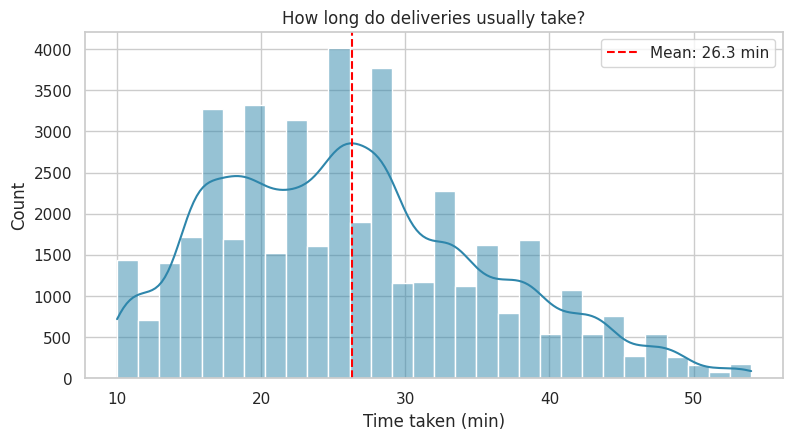

In [4]:
plt.figure(figsize=(9, 4.5))
sns.histplot(df['Time_taken (min)'], kde=True, color='#2E86AB', bins=30)
plt.axvline(df['Time_taken (min)'].mean(), color='red', linestyle='--', label=f"Mean: {df['Time_taken (min)'].mean():.1f} min")
plt.title('How long do deliveries usually take?')
plt.xlabel('Time taken (min)')
plt.legend()
plt.show()

## EDA — Dataset Overview

In [ ]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("\nColumns with missing values:\n", missing_df)

plt.figure(figsize=(9, 4.5))
plt.barh(missing_df.index, missing_df['Missing %'], color='#E67E22')
plt.xlabel('% missing')
plt.title('Missing Values by Column (before imputation)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

df.describe()


## EDA — Categorical Feature Distributions

In [ ]:
cat_cols = ['Weather_conditions', 'Road_traffic_density', 'Type_of_vehicle',
            'Type_of_order', 'City', 'Festival']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, hue=col, palette='Reds_r',
                  legend=False, ax=axes[i])
    axes[i].set_title(f'{col} distribution')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## EDA — Delivery Time by Traffic Density

In [ ]:
traffic_order = ['Low', 'Medium', 'High', 'Jam']
plt.figure(figsize=(9, 4.5))
sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df,
            order=traffic_order, hue='Road_traffic_density',
            palette='Reds', legend=False)
plt.title('Delivery Time by Traffic Density')
plt.xlabel('Traffic Density')
plt.ylabel('Time Taken (min)')
plt.tight_layout()
plt.show()

print(df.groupby('Road_traffic_density')['Time_taken (min)'].mean().reindex(traffic_order).round(1))


## EDA — Delivery Time by City Type & Vehicle Type

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x='City', y='Time_taken (min)', data=df, hue='City',
            palette='Blues', legend=False, ax=axes[0])
axes[0].set_title('Delivery Time by City Type')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(x='Type_of_vehicle', y='Time_taken (min)', data=df, hue='Type_of_vehicle',
            palette='Greens', legend=False, ax=axes[1])
axes[1].set_title('Delivery Time by Vehicle Type')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## EDA — Delivery Person Age & Ratings vs Delivery Time

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.regplot(x='Delivery_person_Age', y='Time_taken (min)', data=df,
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#2E86AB'},
            line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('Delivery Person Age vs Delivery Time')

sns.regplot(x='Delivery_person_Ratings', y='Time_taken (min)', data=df,
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#8E44AD'},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Delivery Person Rating vs Delivery Time')

plt.tight_layout()
plt.show()

age_corr, _ = pearsonr(df['Delivery_person_Age'], df['Time_taken (min)'])
rating_corr, _ = pearsonr(df['Delivery_person_Ratings'], df['Time_taken (min)'])
print(f"Age vs Time: r = {age_corr:.2f}")
print(f"Rating vs Time: r = {rating_corr:.2f}")


## EDA — Multiple Deliveries & Festival Impact

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

md_data = df.dropna(subset=['multiple_deliveries'])
sns.boxplot(x='multiple_deliveries', y='Time_taken (min)', data=md_data,
            hue='multiple_deliveries', palette='Oranges', legend=False, ax=axes[0])
axes[0].set_title('Delivery Time by No. of Multiple Deliveries')

sns.boxplot(x='Festival', y='Time_taken (min)', data=df,
            hue='Festival', palette='Purples', legend=False, ax=axes[1])
axes[1].set_title('Delivery Time: Festival vs Non-Festival Days')

plt.tight_layout()
plt.show()


## EDA — Correlation Heatmap (Raw Numeric Features)

In [ ]:
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Time_taken (min)']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Raw Numeric Features')
plt.tight_layout()
plt.show()


## EDA — Outlier Check on Target Variable

In [ ]:
plt.figure(figsize=(9, 2.5))
sns.boxplot(x=df['Time_taken (min)'], color='#C0392B')
plt.title('Time Taken (min) — Outlier Check')
plt.tight_layout()
plt.show()

q1, q3 = df['Time_taken (min)'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df['Time_taken (min)'] < lower) | (df['Time_taken (min)'] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}] minutes")
print(f"Outliers beyond IQR bounds: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}% of data)")


## Handle Missing Values

In [5]:
for col in ['Weather_conditions', 'Road_traffic_density', 'Type_of_order',
            'Type_of_vehicle', 'Festival', 'City']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].mode()[0])
print("Missing values left:", df.isnull().sum().sum())

Missing values left: 91


## Feature Engineering — Distance (Haversine)

In [6]:
for c in ['Restaurant_latitude', 'Restaurant_longitude',
          'Delivery_location_latitude', 'Delivery_location_longitude']:
    df[c] = df[c].abs()

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['Distance_km'] = haversine_distance(
    df['Restaurant_latitude'], df['Restaurant_longitude'],
    df['Delivery_location_latitude'], df['Delivery_location_longitude']
)
print(df['Distance_km'].describe())

count    43676.000000
mean         9.732210
std          5.603589
min          1.465067
25%          4.663412
50%          9.220148
75%         13.681388
max         20.969489
Name: Distance_km, dtype: float64


## Feature Engineering — Time Features

In [7]:
def parse_hour(t):
    try:
        t = str(t)
        if ':' in t:
            return int(t.split(':')[0]) % 24
        return int(round(float(t) * 24)) % 24
    except Exception:
        return np.nan

df['Order_Hour'] = df['Time_Orderd'].apply(parse_hour)
df['Order_Hour'] = df['Order_Hour'].fillna(df['Order_Hour'].mode()[0])
df['Is_Rush_Hour'] = df['Order_Hour'].apply(lambda h: 1 if h in [8, 9, 12, 13, 19, 20, 21] else 0)
print(df[['Order_Hour', 'Is_Rush_Hour']].isnull().sum())

Order_Hour      0
Is_Rush_Hour    0
dtype: int64


## Categorical Encoding

In [8]:
# Map traffic and festival columns to numerical values
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
df['Road_traffic_density'] = df['Road_traffic_density'].map(traffic_map)
df['Festival'] = df['Festival'].map({'No': 0, 'Yes': 1})

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=['Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'City'], drop_first=True)

# Convert boolean columns to integers (0 and 1)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Print the final shape
print("Shape:", df_encoded.shape)

Shape: (43676, 32)


## EDA — Weather Impact

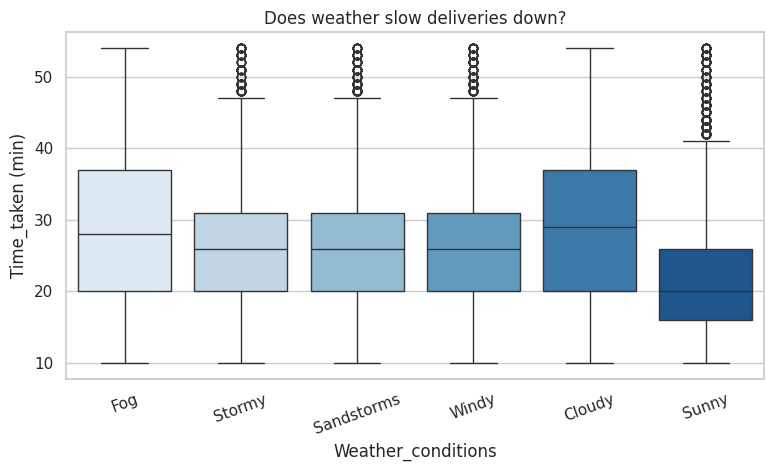

In [9]:
plt.figure(figsize=(9, 4.5))
sns.boxplot(x='Weather_conditions', y='Time_taken (min)', data=df,
            hue='Weather_conditions', palette='Blues', legend=False)
plt.title('Does weather slow deliveries down?')
plt.xticks(rotation=20)
plt.show()

## Train-Test Split

In [10]:
feature_cols = [c for c in df_encoded.columns
                if c not in ['ID', 'Delivery_person_ID', 'Order_Date',
                             'Time_Orderd', 'Time_Order_picked',
                             'Restaurant_latitude', 'Restaurant_longitude',
                             'Delivery_location_latitude', 'Delivery_location_longitude',
                             'Time_taken (min)']]

X = df_encoded[feature_cols]
y = df_encoded['Time_taken (min)']
print("Any missing values in X?", X.isnull().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Any missing values in X? 0
Train: (34940, 22) | Test: (8736, 22)


## Correlation Analysis

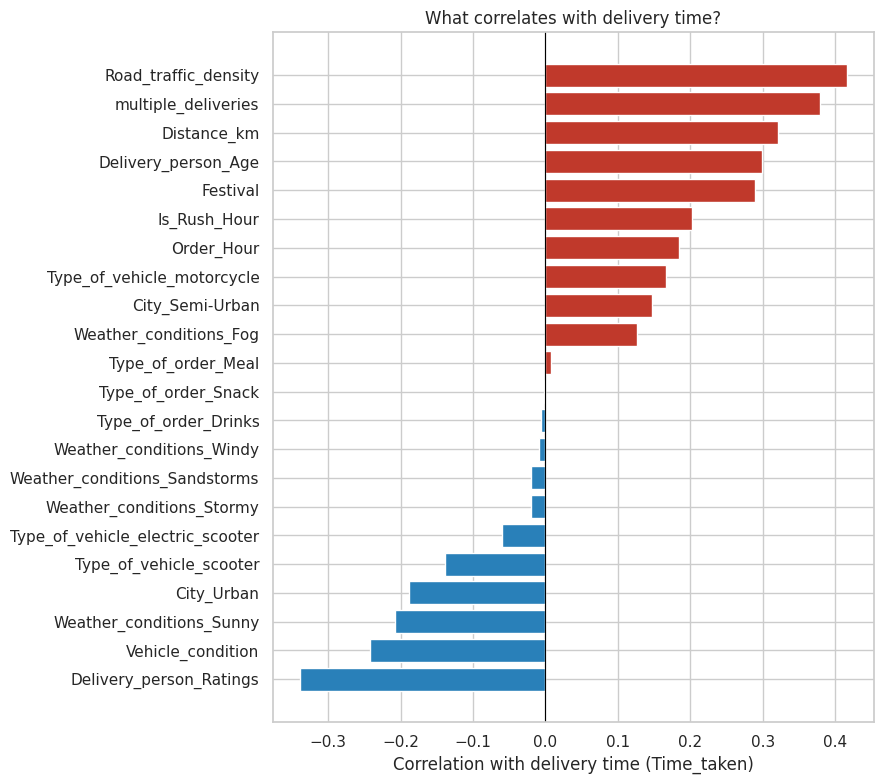

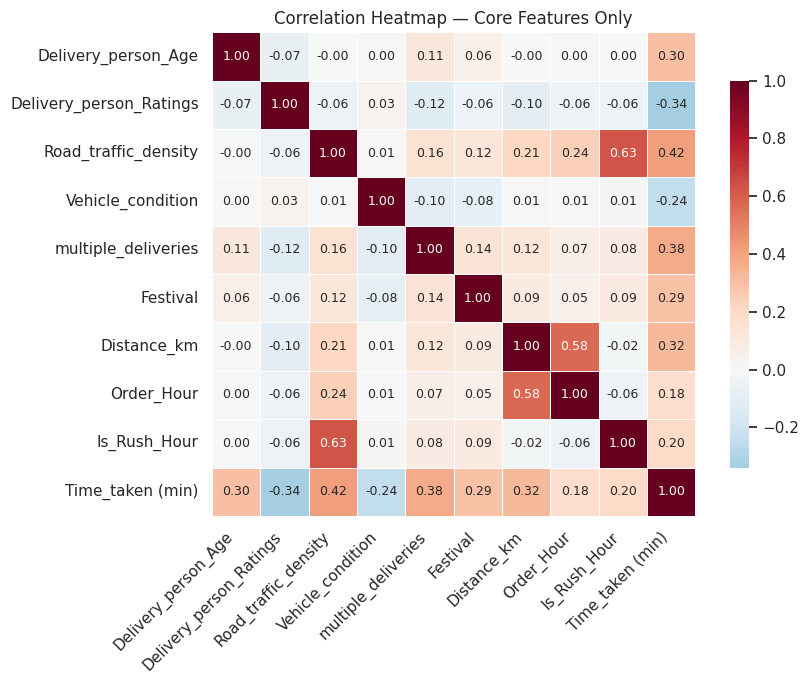

In [11]:
# --- Chart A: what actually correlates with delivery time (sorted, easy to read) ---
numeric_df = df_encoded.select_dtypes(include=[np.number]).drop(columns=[
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude'
], errors='ignore')

target_corr = numeric_df.corr()['Time_taken (min)'].drop('Time_taken (min)').sort_values()

plt.figure(figsize=(9, 8))
colors = ['#c0392b' if v > 0 else '#2980b9' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with delivery time (Time_taken)')
plt.title('What correlates with delivery time?')
plt.tight_layout()
plt.show()

# --- Chart B: full heatmap, but only the core numeric/ordinal features ---
core_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Road_traffic_density',
             'Vehicle_condition', 'multiple_deliveries', 'Festival', 'Distance_km',
             'Order_Hour', 'Is_Rush_Hour', 'Time_taken (min)']
core_corr = df_encoded[core_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(core_corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 9}, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Core Features Only')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Benchmarking — 5 Baseline Models

In [12]:
models_to_try = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
fitted_models = {}

for name, model in models_to_try.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae_ = mean_absolute_error(y_test, preds)
    rmse_ = np.sqrt(mean_squared_error(y_test, preds))
    r2_ = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE (minutes)': round(mae_, 2),
                     'RMSE': round(rmse_, 2), 'R2 Score': round(r2_, 3)})
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('MAE (minutes)').reset_index(drop=True)
print(results_df.to_string(index=False))

            Model  MAE (minutes)  RMSE  R2 Score
    Random Forest           3.11  3.88     0.827
    Decision Tree           3.50  4.41     0.777
Gradient Boosting           3.58  4.47     0.770
 Ridge Regression           4.83  6.04     0.581
Linear Regression           4.83  6.04     0.581


## XGBoost — Untuned Baseline

In [13]:
xgb_baseline = xgb.XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
xgb_baseline.fit(X_train, y_train)
xgb_preds = xgb_baseline.predict(X_test)

results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': 'XGBoost (untuned)',
    'MAE (minutes)': round(mean_absolute_error(y_test, xgb_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, xgb_preds)), 2),
    'R2 Score': round(r2_score(y_test, xgb_preds), 3)
}])], ignore_index=True)
fitted_models['XGBoost (untuned)'] = xgb_baseline
print(results_df.to_string(index=False))

            Model  MAE (minutes)  RMSE  R2 Score
    Random Forest           3.11  3.88     0.827
    Decision Tree           3.50  4.41     0.777
Gradient Boosting           3.58  4.47     0.770
 Ridge Regression           4.83  6.04     0.581
Linear Regression           4.83  6.04     0.581
XGBoost (untuned)           3.12  3.87     0.828


## Hyperparameter Tuning (RandomizedSearchCV)

In [14]:
xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.05, 0.08, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_grid,
    n_iter=15, cv=5, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print("Best parameters:", xgb_search.best_params_)

xgb_tuned = xgb_search.best_estimator_
xgb_tuned_preds = xgb_tuned.predict(X_test)

results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': 'XGBoost (tuned)',
    'MAE (minutes)': round(mean_absolute_error(y_test, xgb_tuned_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, xgb_tuned_preds)), 2),
    'R2 Score': round(r2_score(y_test, xgb_tuned_preds), 3)
}])], ignore_index=True).sort_values('MAE (minutes)').reset_index(drop=True)
fitted_models['XGBoost (tuned)'] = xgb_tuned
print(results_df.to_string(index=False))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
            Model  MAE (minutes)  RMSE  R2 Score
  XGBoost (tuned)           3.04  3.77     0.837
    Random Forest           3.11  3.88     0.827
XGBoost (untuned)           3.12  3.87     0.828
    Decision Tree           3.50  4.41     0.777
Gradient Boosting           3.58  4.47     0.770
 Ridge Regression           4.83  6.04     0.581
Linear Regression           4.83  6.04     0.581


## Final Model Selection

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best model: {best_model_name}")
print(f"MAE: {mae:.2f} minutes")
print(f"R2 Score: {r2:.3f}")

Best model: XGBoost (tuned)
MAE: 3.04 minutes
R2 Score: 0.837


## Model Comparison Chart

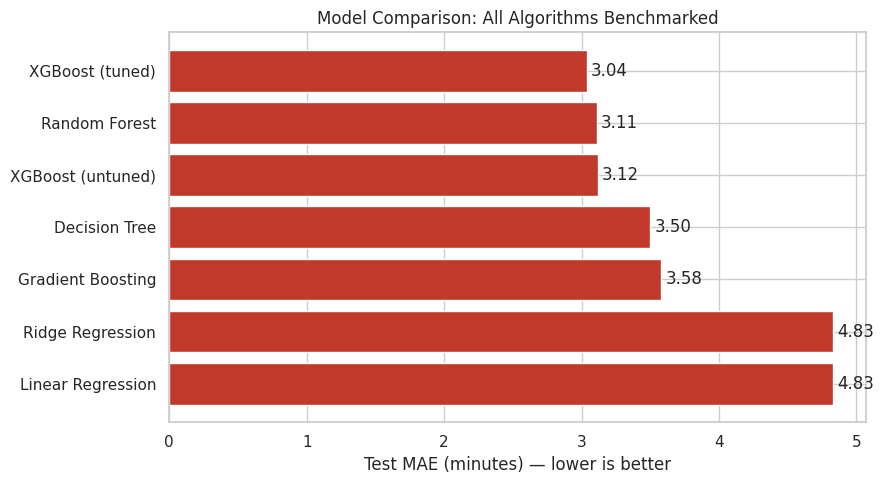

In [16]:
plt.figure(figsize=(9, 5))
plot_df = results_df.sort_values('MAE (minutes)', ascending=True)
bars = plt.barh(plot_df['Model'], plot_df['MAE (minutes)'], color='#C0392B')
plt.xlabel('Test MAE (minutes) — lower is better')
plt.title('Model Comparison: All Algorithms Benchmarked')
for bar in bars:
    plt.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
              f'{bar.get_width():.2f}', va='center')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Validation — Residual Analysis

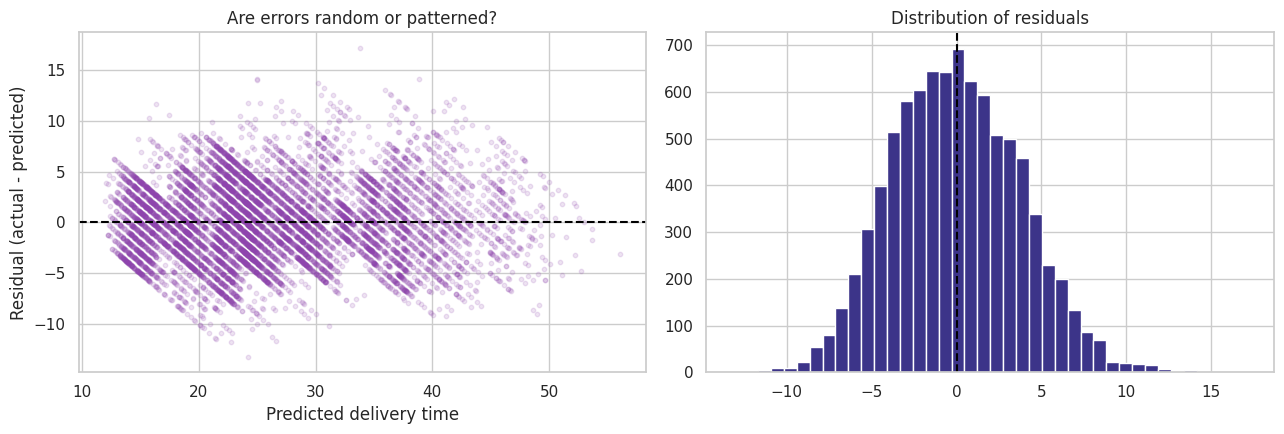

Mean residual (should be close to 0): -0.01 minutes


In [17]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred, residuals, alpha=0.15, s=10, color='#8E44AD')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted delivery time')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Are errors random or patterned?')

axes[1].hist(residuals, bins=40, color='#3c3489')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribution of residuals')
plt.tight_layout()
plt.show()
print(f"Mean residual (should be close to 0): {residuals.mean():.2f} minutes")

## Model Validation — Overfitting Check

In [18]:
train_pred = best_model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_pred)
print(f"Train MAE: {train_mae:.2f} | Test MAE: {mae:.2f} | Gap: {mae - train_mae:.2f}")
print("GOOD: generalizes well" if (mae - train_mae) <= 1.0 else "WARNING: possible overfitting")

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = -cross_val_score(best_model, X_train, y_train, cv=kf,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"CV scores: {np.round(cv_scores, 2)}")
print(f"Average: {cv_scores.mean():.2f} | Std: {cv_scores.std():.2f}")

Train MAE: 2.83 | Test MAE: 3.04 | Gap: 0.22
GOOD: generalizes well
CV scores: [2.99 3.09 3.1  3.09 3.1  3.1  3.03 3.07 3.09 3.07]
Average: 3.07 | Std: 0.03


## Model Validation — Predicted vs Actual

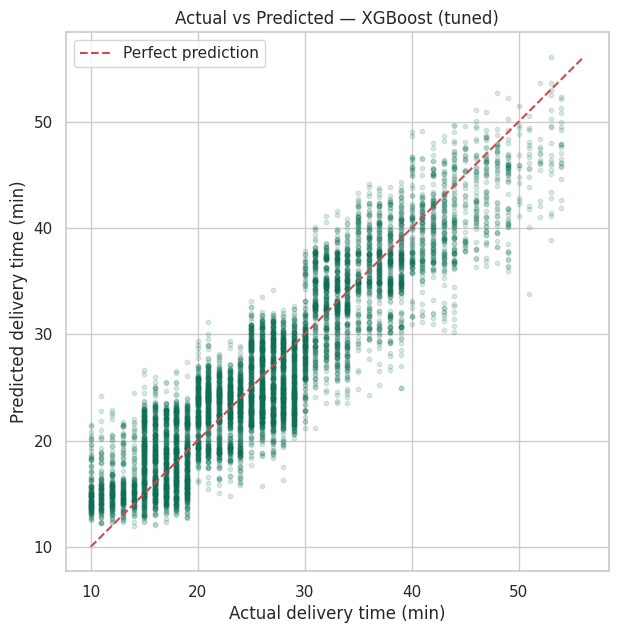

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.15, s=10, color='#0F6E56')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual delivery time (min)')
plt.ylabel('Predicted delivery time (min)')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.show()

## Business Insight — Distance vs Traffic

Correlation Distance_km vs Time_taken: r = 0.32 (r^2 = 0.10)


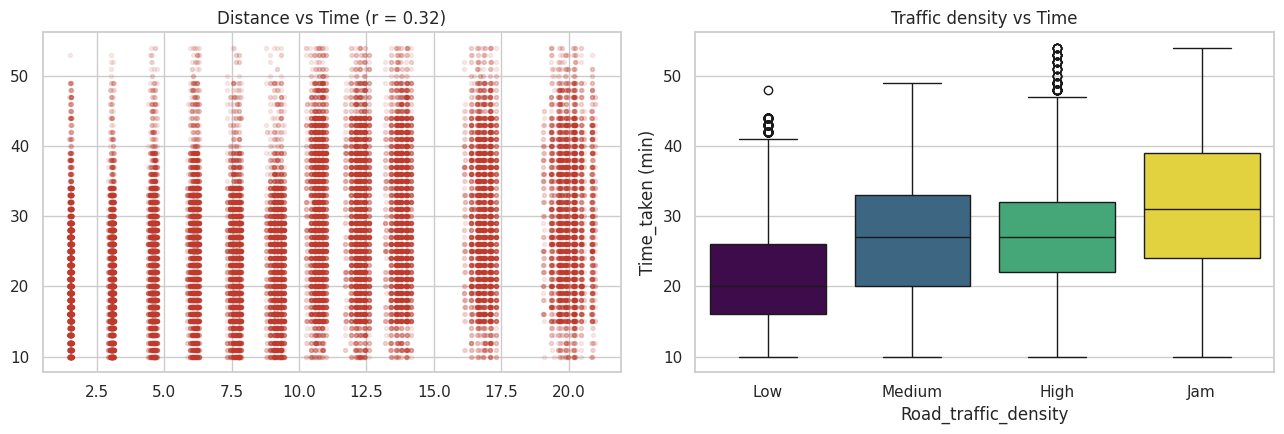

In [20]:
corr, _ = pearsonr(df_encoded['Distance_km'], df_encoded['Time_taken (min)'])
print(f"Correlation Distance_km vs Time_taken: r = {corr:.2f} (r^2 = {corr**2:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(df_encoded['Distance_km'], df_encoded['Time_taken (min)'], alpha=0.1, s=8, color='#c0392b')
axes[0].set_title(f'Distance vs Time (r = {corr:.2f})')

sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df_encoded,
            order=[0, 1, 2, 3], hue='Road_traffic_density', palette='viridis', legend=False, ax=axes[1])
axes[1].set_xticklabels(['Low', 'Medium', 'High', 'Jam'])
axes[1].set_title('Traffic density vs Time')
plt.tight_layout()
plt.show()

## Model Explainability (SHAP)

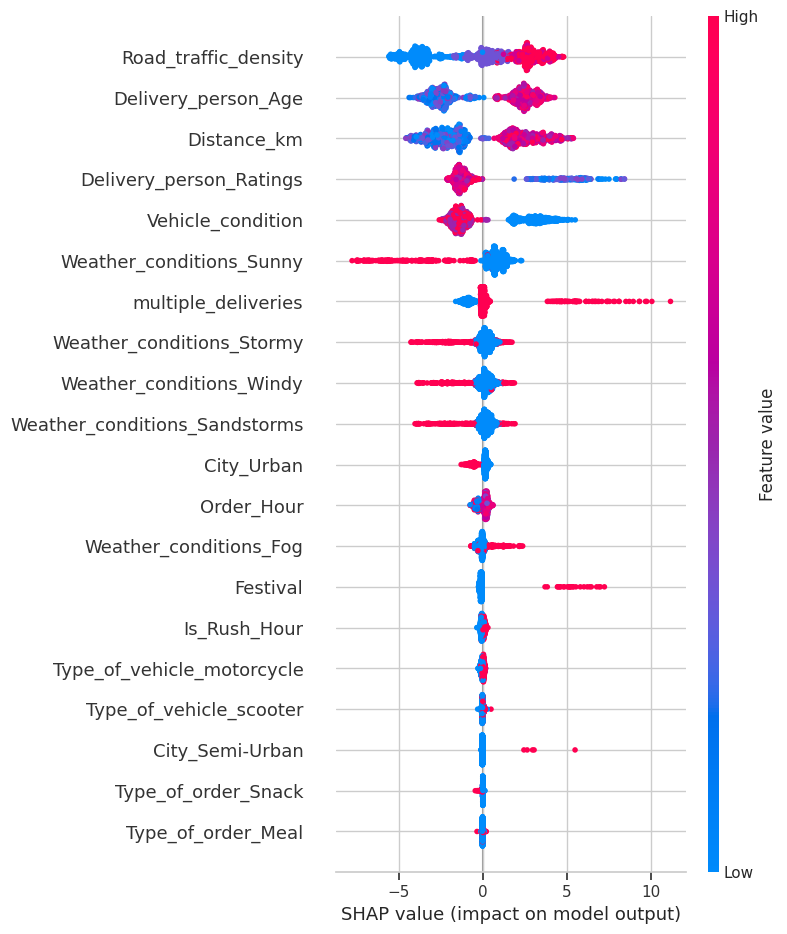

                      Feature  Avg. impact on ETA (minutes)
         Road_traffic_density                      2.592335
          Delivery_person_Age                      2.559369
                  Distance_km                      2.416900
      Delivery_person_Ratings                      2.008185
            Vehicle_condition                      1.977373
     Weather_conditions_Sunny                      1.346347
          multiple_deliveries                      0.615980
    Weather_conditions_Stormy                      0.506245
     Weather_conditions_Windy                      0.505268
Weather_conditions_Sandstorms                      0.457815


In [21]:
sample_size = min(1500, len(X_test))
X_shap_sample = X_test.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_sample)
shap.summary_plot(shap_values, X_shap_sample, show=True)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': X_shap_sample.columns,
    'Avg. impact on ETA (minutes)': mean_abs_shap
}).sort_values('Avg. impact on ETA (minutes)', ascending=False).head(10)
print(shap_importance.to_string(index=False))

## Feature Importance Chart

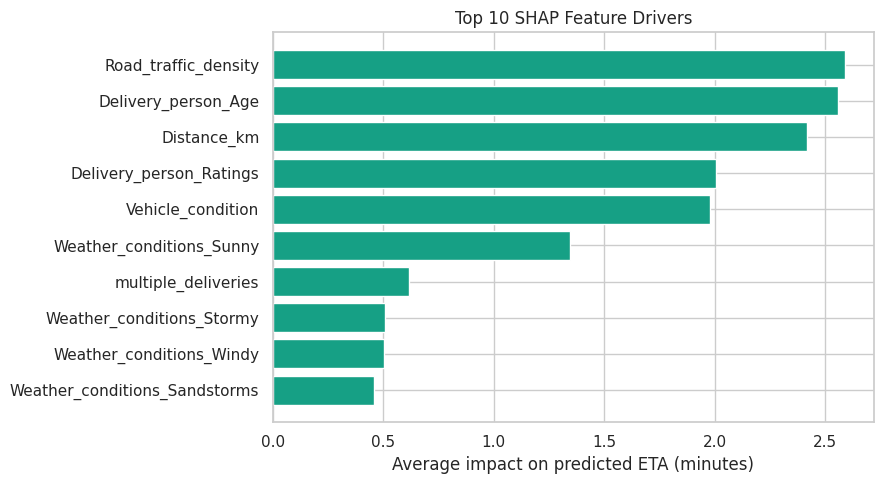

In [22]:
plt.figure(figsize=(9, 5))
plt.barh(shap_importance['Feature'], shap_importance['Avg. impact on ETA (minutes)'], color='#16A085')
plt.xlabel('Average impact on predicted ETA (minutes)')
plt.title('Top 10 SHAP Feature Drivers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Save Final Model

In [23]:
joblib.dump(best_model, 'zomato_delivery_model.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')
print(f"Model '{best_model_name}' saved. MAE = {mae:.2f} minutes")

Model 'XGBoost (tuned)' saved. MAE = 3.04 minutes


## Export Model Artifacts

In [24]:
from google.colab import files
files.download('zomato_delivery_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import os
print(os.path.exists('zomato_delivery_model.pkl'))
print(os.path.getsize('zomato_delivery_model.pkl'), 'bytes')

True
1642203 bytes


In [27]:
results_df.to_csv('model_comparison.csv', index=False)
print("Model comparison saved.")

Model comparison saved.


In [28]:
from google.colab import files
files.download('model_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Export Dashboard Data

In [33]:
dashboard_data = df_encoded[['Time_taken (min)', 'Distance_km', 'Road_traffic_density',
                               'Delivery_person_Age', 'Delivery_person_Ratings',
                               'multiple_deliveries', 'Order_Hour']].sample(5000, random_state=42)
dashboard_data.to_csv('dashboard_data.csv', index=False)

shap_importance.to_csv('shap_importance.csv', index=False)

print("Dashboard data exported.")

Dashboard data exported.


In [31]:
from google.colab import files
files.download('dashboard_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
files.download('shap_importance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>